In [4]:
import scanpy as sc
import pandas as pd
import numpy as np

/home/gzu5140/.conda/envs/twinfer-code/lib/python3.12/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


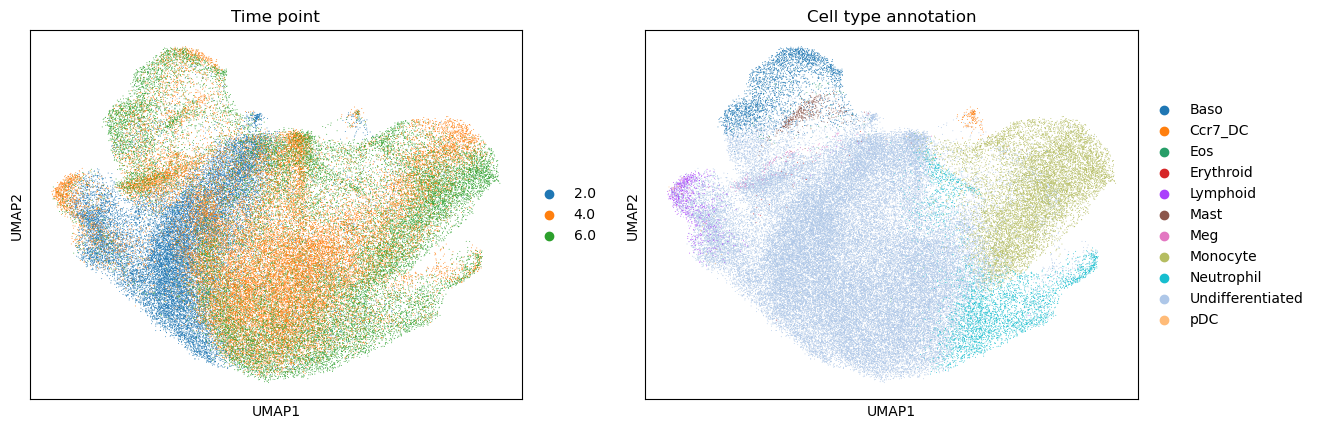

In [5]:
adata_path = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/real_data/LSK_d2_d4_d6.h5ad"
adata = sc.read_h5ad(adata_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

In [2]:
import pandas as pd

df = pd.read_excel(
    "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/TwINFER_verification/Mouse_TFs_Kinases_webpage-3-30-2017.xlsx",
    header=None,
    index_col=None
)

# first non-empty row = real header
header_row = df.dropna(how="all").index[0]

# set column names
df.columns = df.loc[header_row].astype(str)

# drop header row and empty rows
all_gene_list_TF = (
    df
    .iloc[header_row + 1 :]
    .dropna(how="all")
    .reset_index(drop=True)
)

gene_TF = all_gene_list_TF['Gene Symbol']

In [6]:
#Check that all of these genes are present in the dataset (since sometimes they have alternate names. E.g. Pu1 is names Spi1)
gene_list_check = gene_TF

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)
print("❌ Not found in dataset", not_found)

Found 1400 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff3', 'aff4', 'ahr', 'ahrr', 'ai987944', 'aire', 'alx1', 'alx3', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl1', 'ascl2', 'ascl3', 'ascl4', 'ascl5', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'atoh1', 'atoh7', 'atoh8', 'au041133', 'aw146154', 'aw822073', 'bach1', 'bach2', 'barhl1', 'barhl2', 'barx1', 'barx2', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bcl6b', 'bhlha15', 'bhlha9', 'bhlhe22', 'bhlhe23', 'bhlhe40', 'bhlhe41', 'bnc2', 'bsx', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cdx1', 'cdx2', 'cdx4', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers3', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'cphx1', 'cphx2', 'cphx3', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l3', 'creb3l4', 'creb

In [7]:
adata_day_2 = adata[adata.obs['Time point'] == 2].copy()
sc.pp.filter_genes(adata_day_2, min_cells=10)

all_genes = {g.lower() for g in adata_day_2.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found_day_2 = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found_day_2)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)

print("❌ Not found in dataset", not_found)

Found 904 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff3', 'aff4', 'ahr', 'ahrr', 'ai987944', 'aire', 'alx1', 'alx3', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl1', 'ascl2', 'ascl3', 'ascl4', 'ascl5', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'atoh1', 'atoh7', 'atoh8', 'au041133', 'aw146154', 'aw822073', 'bach1', 'bach2', 'barhl1', 'barhl2', 'barx1', 'barx2', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bcl6b', 'bhlha15', 'bhlha9', 'bhlhe22', 'bhlhe23', 'bhlhe40', 'bhlhe41', 'bnc2', 'bsx', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cdx1', 'cdx2', 'cdx4', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers3', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'cphx1', 'cphx2', 'cphx3', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l3', 'creb3l4', 'crebz

In [8]:
adata_day_4 = adata[adata.obs['Time point'] == 4].copy()
sc.pp.filter_genes(adata_day_4, min_cells=10)
gene_list_check = gene_TF
all_genes = {g.lower() for g in adata_day_4.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found_day_4 = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found_day_4)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found_day_4)

print("❌ Not found in dataset", not_found)

Found 943 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff4', 'ahr', 'ahrr', 'ai987944', 'aire', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl4', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'atoh8', 'au041133', 'aw146154', 'bach1', 'bach2', 'barhl1', 'barhl2', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bcl6b', 'bhlha15', 'bhlhe40', 'bhlhe41', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l4', 'crebzf', 'crem', 'crx', 'csdc2', 'csde1', 'ctcf', 'cux1', 'd3ertd254e', 'dbp', 'ddit3', 'deaf1', 'dlx1', 'dlx6', 'dmbx1', 'dmrta2', 'dmtf1', 'dnajc1', 'dnajc2', 'e2f1', 'e2f2', 'e2f3', 'e2f4', 'e2f5', 'e2f6', 'e2f7', 'e2f8', 'e4300

In [9]:
adata_day_6 = adata[adata.obs['Time point'] == 6].copy()
sc.pp.filter_genes(adata_day_6, min_cells=10)

gene_list_check = gene_TF

all_genes = {g.lower() for g in adata_day_6.var_names}
gene_list_check =  [g.lower() for g in gene_list_check]
found_day_6 = [a for a in gene_list_check if a in all_genes]
not_found = [a for a in gene_list_check if a not in all_genes]
print(f"Found {len(found_day_6)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found_day_6)

print("❌ Not found in dataset", not_found)

Found 944 genes out of 1482
✅ Found gene(s): ['adnp', 'aebp2', 'aff1', 'aff2', 'aff4', 'ahr', 'ahrr', 'ai987944', 'alx4', 'ar', 'arid1a', 'arid1b', 'arid2', 'arid3a', 'arid3b', 'arid3c', 'arid4a', 'arid4b', 'arid5a', 'arid5b', 'arnt', 'arnt2', 'arntl', 'arntl2', 'arx', 'ascl2', 'ascl4', 'atf1', 'atf2', 'atf3', 'atf4', 'atf5', 'atf6', 'atf6b', 'atf7', 'atf7', 'au041133', 'aw146154', 'bach1', 'bach2', 'barhl1', 'batf', 'batf2', 'batf3', 'baz2b', 'bbx', 'bc025920', 'bcl11a', 'bcl11b', 'bcl6', 'bhlha15', 'bhlhe40', 'bhlhe41', 'c030039l03rik', 'camta1', 'camta2', 'carhsp1', 'cbfb', 'cdc5l', 'cdip1', 'cebpa', 'cebpb', 'cebpe', 'cebpg', 'cers2', 'cers4', 'cers5', 'cers6', 'cic', 'clock', 'creb1', 'creb3', 'creb3l1', 'creb3l2', 'creb3l3', 'creb3l4', 'crebzf', 'crem', 'crxos', 'csdc2', 'csde1', 'ctcf', 'cux1', 'cux2', 'd3ertd254e', 'dbp', 'ddit3', 'deaf1', 'dlx1', 'dlx6', 'dmrt2', 'dmrta2', 'dmtf1', 'dnajc1', 'dnajc2', 'e2f1', 'e2f2', 'e2f3', 'e2f4', 'e2f5', 'e2f6', 'e2f7', 'e2f8', 'e430018j23r

In [13]:
continuously_expressed_genes = set(found_day_2).intersection(set(found_day_4)).intersection(set(found_day_6))
len(continuously_expressed_genes)

868

In [14]:
#Gene set to use for current analysis
gene_set_name = "all_TF" #For Neutrohils, modify this to Neutrophil
curr_gene_list = continuously_expressed_genes
gene_subset = [s + '_mRNA' for s in curr_gene_list]

In [26]:
present_tfs = [tf for tf in continuously_expressed_genes if tf in adata_day_2.var_names]
adata_day_2.var_names.to_list()


['0610007P14Rik',
 '0610009B22Rik',
 '0610009E02Rik',
 '0610009L18Rik',
 '0610009O20Rik',
 '0610010F05Rik',
 '0610010K14Rik',
 '0610011F06Rik',
 '0610012D04Rik',
 '0610012G03Rik',
 '0610030E20Rik',
 '0610031O16Rik',
 '0610037L13Rik',
 '0610038B21Rik',
 '0610040B10Rik',
 '0610040J01Rik',
 '1110001J03Rik',
 '1110002L01Rik',
 '1110004E09Rik',
 '1110004F10Rik',
 '1110008F13Rik',
 '1110008L16Rik',
 '1110008P14Rik',
 '1110012L19Rik',
 '1110019D14Rik',
 '1110020A21Rik',
 '1110028F11Rik',
 '1110032A03Rik',
 '1110032F04Rik',
 '1110034G24Rik',
 '1110037F02Rik',
 '1110038B12Rik',
 '1110038F14Rik',
 '1110046J04Rik',
 '1110051M20Rik',
 '1110059E24Rik',
 '1110059G10Rik',
 '1110065P20Rik',
 '1190002N15Rik',
 '1190005I06Rik',
 '1190007I07Rik',
 '1300002E11Rik',
 '1500004A13Rik',
 '1500009L16Rik',
 '1500011B03Rik',
 '1500011K16Rik',
 '1500017E21Rik',
 '1500026H17Rik',
 '1600002H07Rik',
 '1600002K03Rik',
 '1600010M07Rik',
 '1600012H06Rik',
 '1600014C10Rik',
 '1600014C23Rik',
 '1600020E01Rik',
 '1600029O

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

# Assume 'adata' is your preprocessed AnnData object
# and 'tf_list' is a Python list of your TFs of interest

# 1. Filter the AnnData object to keep only the TFs in your list
# Ensure that the TFs in your list are present in the adata object
present_tfs = [tf for tf in continuously_expressed_genes if tf in adata_day_2.var_names.to_list()]

In [25]:
if not present_tfs:
    print("None of the TFs in the provided list were found in the AnnData object.")
else:
    # Create a subset AnnData object containing only the TFs
    adata_tfs = adata_day_2[:, present_tfs]

    # 2. Calculate the mean expression of each TF across all cells
    # Use .X for the main expression matrix (counts/normalized counts)
    # The mean function needs an axis argument. For n_obs x n_vars (cells x genes), axis=0 calculates the mean per gene.
    # If the data is sparse, use .mean(axis=0).A1 to get a dense numpy array of means.
    if isinstance(adata_tfs.X, (sc.external.pynndescent.NumpyAnnData, np.ndarray)):
        mean_expression = adata_tfs.X.mean(axis=0)
    else:
        mean_expression = adata_tfs.X.mean(axis=0).A1
    
    # 3. Create a pandas DataFrame to store TF names and their mean expression
    expression_df = pd.DataFrame({
        'Gene': adata_tfs.var_names,
        'MeanExpression': mean_expression
    })

    # 4. Sort the DataFrame by mean expression in descending order
    expression_df.sort_values(by='MeanExpression', ascending=False, inplace=True)

    # 5. Get the top 100 TFs
    top_100_tfs = expression_df.head(100)

    # 6. Print or use the list of top 100 TFs
    print("Top 100 highly expressed TFs:")
    print(top_100_tfs['Gene'].tolist())

    # To get the dataframe itself
    # print(top_100_tfs)


None of the TFs in the provided list were found in the AnnData object.


In [19]:
adata_day_2.obs

,Library,Time point,Starting population,Cell type annotation,Well,SPRING-x,SPRING-y,clone_id,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt
Cell barcode,,,,,,,,,,,,,,,,
TCGCAATC-GAGAGTAT,LSK_d2_2,2.0,Lin-Kit+Sca1+,Undifferentiated,0,-71.630,1028.776,4187,1245,2878.748779,31.583465,40.833499,51.875207,68.958687,429.413391,14.916667
CCTACGCT-CGAACGTA,LSK_d2_2,2.0,Lin-Kit+Sca1+,Undifferentiated,0,313.588,894.460,-1,2928,2878.748779,23.040702,30.189395,39.419193,55.149007,258.309357,8.972974
ACGACGAC-AAGTAATC,LSK_d2_2,2.0,Lin-Kit+Sca1+,Undifferentiated,0,1092.618,37.998,-1,2647,2878.749023,22.264194,29.617070,39.436724,56.625074,276.767761,9.614168
ATGACTTG-GAGCCCAT,LSK_d2_2,2.0,Lin-Kit+Sca1+,Undifferentiated,0,-6.790,486.925,-1,2371,2878.749268,26.815990,34.697717,44.173906,59.556857,294.186340,10.219242
GAAAGACA-TTGTGACT,LSK_d2_2,2.0,Lin-Kit+Sca1+,Undifferentiated,0,33.385,880.870,94,751,2878.749023,28.994118,39.729554,53.423585,78.782849,299.312012,10.397294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTTGCCT-CTGTTCTT-1,LSK_d2_1,2.0,Lin-Kit+Sca1+,Undifferentiated,0,-1.257,667.182,-1,528,2878.748779,32.689935,44.916486,57.786540,96.396706,414.954803,14.414414
TACGCGAG-AGCGAAGT-1,LSK_d2_1,2.0,Lin-Kit+Sca1+,Undifferentiated,0,71.706,498.514,-1,364,2878.748779,40.219399,51.736773,70.018308,100.000076,452.600372,15.722121
CGACATTT-TACCAGGC-1,LSK_d2_1,2.0,Lin-Kit+Sca1+,Undifferentiated,0,790.400,1643.254,-1,370,2878.748779,35.393350,49.438337,68.164998,100.000339,291.109436,10.112360


### Grnboost

In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
from arboreto.utils import load_tf_names
from arboreto.algo import grnboost2

In [ ]:
import subprocess
from pathlib import Path

repo = Path("/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER")

cmd = """
module load git-lfs
git lfs pull --include=real_data/LSK_d2_d4_d6.h5ad
"""

result = subprocess.run(
    ["bash", "-lc", cmd],
    cwd=repo,
    capture_output=True,
    text=True,
)

print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return code:", result.returncode)


/home/gzu5140/.conda/envs/grnboost310/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


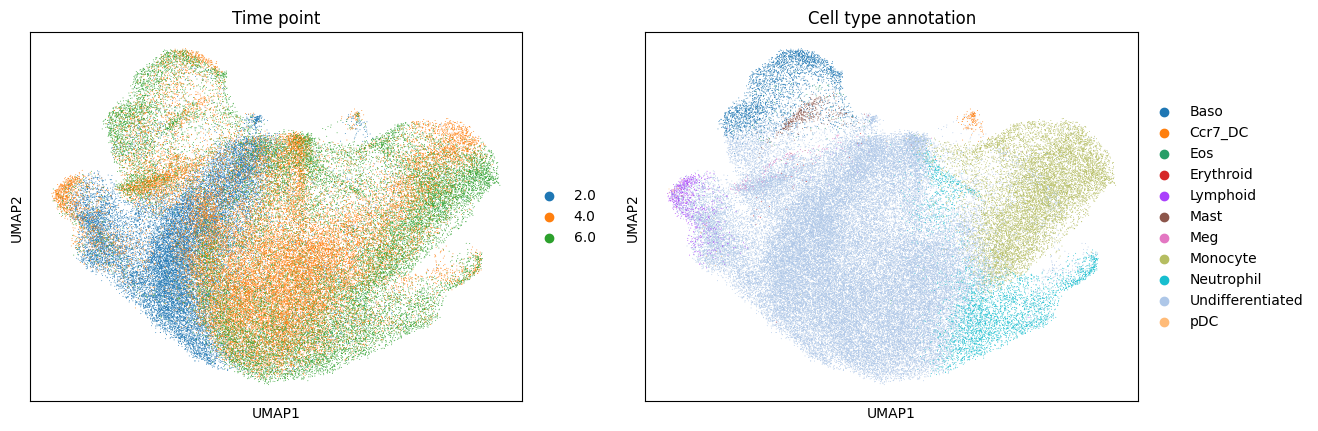

In [3]:
#Load the h5ad file
# Define the full path to the data file
path_to_code_repo = "/home/gzu5140/Keerthana_b1042/grnInference/code/TwINFER/"
data_path = f"{path_to_code_repo}/real_data/"
file_path = f'{data_path}LSK_d2_d4_d6.h5ad'
adata = sc.read_h5ad(file_path)
adata.obs_names_make_unique()
# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

In [ ]:
adata.obs['cell_id'] = adata.obs.index
t1 = 2
curr_gene_list = ['Gata1', 'Gata2', 'Gfi1', 'Fli1', 'Spi1', 'Tal1',  'Cebpa', 'Jun', 'Egr1', 'Nab2', 'Klf1', 'Zfpm1'] #TF involved in hematopoiesis regulation
adata_t1_all = adata[(adata.obs['Time point'] == t1)].copy()
# All cells at time t1 to calculate gene correlation
def make_all_cells_table(adata_t, timepoint, gene_subset, curr_gene_list):
    # add expression
    df = adata_t[:,curr_gene_list].X.toarray()

    return df

gene_subset = [s + '_mRNA' for s in curr_gene_list]
t1_data_all_cells = make_all_cells_table(
    adata_t1_all, t1, gene_subset, curr_gene_list
)
t1_data_all_cells

In [12]:
expr_data = adata_t1_all.to_df()

In [ ]:
expr = expr_data

all_genes = set(expr.columns)
tf_genes = set(curr_gene_list)
target_genes = sorted(all_genes - tf_genes)

print("Genes total:", len(all_genes))
print("TFs:", len(tf_genes))
print("Targets:", len(target_genes))
print("Example targets:", target_genes[:10])

In [ ]:
gene_var = expr.var(axis=0)

valid_targets = [g for g in target_genes if gene_var[g] > 0]

print("Targets with variance > 0:", len(valid_targets))
print("Example valid targets:", valid_targets[:10])


In [31]:
t1_data_all_cells = t1_data_all_cells[gene_subset]

In [ ]:
X = adata_t1_all.to_df().to_numpy(dtype=np.float64)

gene_names = adata_t1_all.to_df().columns.tolist()
tf_names = list(curr_gene_list)

network = grnboost2(
    expression_data=t1_data_all_cells,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
)

In [ ]:
network[:20]

In [44]:
gene_names = [f"gene_{i}_mRNA" for i in np.arange(1,15)]

In [ ]:
df = pd.read_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/figure_4/df_rows_0_0_0_0_0_0_0_0_0_0_0_0_0_0_16012026_065535_ncells_6000_figure_1_network_0_0_ca5e0995.csv")
df_5_gene_network = df[df['time_step'] == 20]
df_5_gene_network = df_5_gene_network[gene_names]
X = df_5_gene_network.to_numpy(dtype=np.float64)

tf_names = list(gene_names)

network = grnboost2(
    expression_data=X,
    gene_names=tf_names,
    tf_names=tf_names,
    verbose=True,
)

In [48]:
# Ensure correct column names
network = network.rename(columns={
    "TF": "tf",
    "target": "target",
    "importance": "importance"
})

# Pivot to TF × target matrix
heatmap_df = network.pivot(
    index="tf",
    columns="target",
    values="importance"
)

# Replace missing edges with 0
heatmap_df = heatmap_df.fillna(0.0)

def to_g_label(name):
    m = re.search(r'(\d+)', str(name))
    return f"g{m.group(1)}" if m else name

heatmap_df = heatmap_df.rename(
    columns=to_g_label,
    index=to_g_label
)

def g_key(name):
    m = re.search(r'(\d+)', str(name))
    return int(m.group(1)) if m else float("inf")

heatmap_df = heatmap_df.sort_index(
    key=lambda idx: [g_key(x) for x in idx]
).sort_index(
    axis=1,
    key=lambda cols: [g_key(x) for x in cols]
)

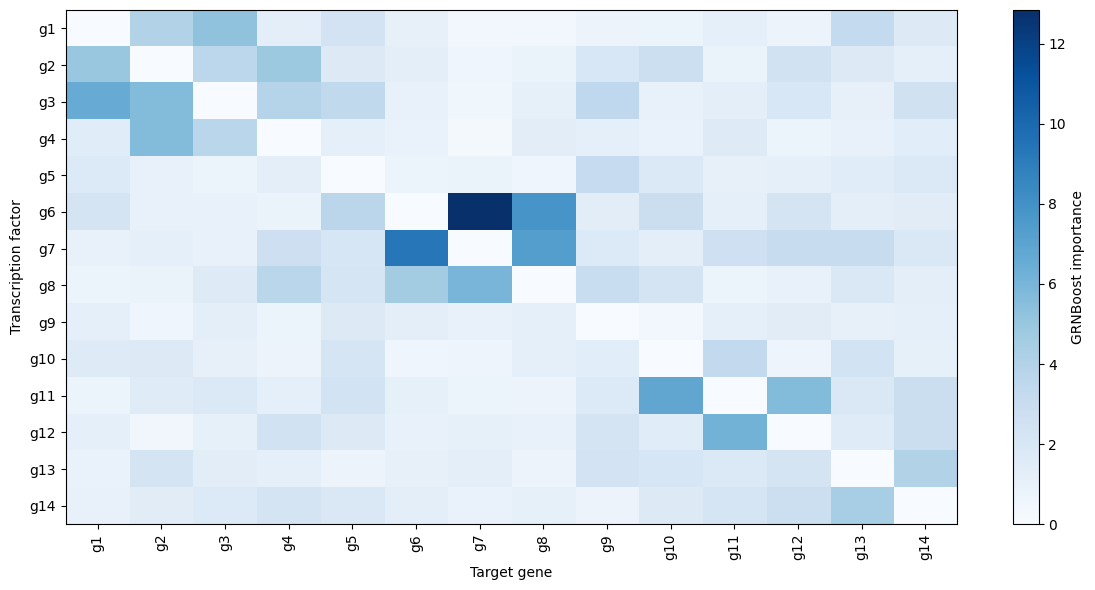

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    interpolation="nearest",
    cmap = "Blues"
)

# Axis labels
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_yticks(np.arange(len(heatmap_df.index)))

ax.set_xticklabels(heatmap_df.columns, rotation=90)
ax.set_yticklabels(heatmap_df.index)

ax.set_xlabel("Target gene")
ax.set_ylabel("Transcription factor")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("GRNBoost importance")

plt.tight_layout()
plt.show()

In [26]:
# GRNBoost2 expects: rows = cells/samples, columns = genes
print(f"Current shape: {X.shape}")
print(f"Number of gene names: {len(gene_names)}")

# If shape[1] != len(gene_names), you might need to transpose:
if X.shape[1] != len(gene_names):
    print("Transposing data...")
    X = X.T

Current shape: (20456, 25289)
Number of gene names: 25289
